In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
import os
from skimage.filters import frangi
from skimage.feature import canny
from skimage.transform import probabilistic_hough_line
from skimage.morphology import skeletonize
from skimage.exposure import rescale_intensity
from skimage.filters import threshold_otsu

from scipy.ndimage import convolve
import math
from itertools import combinations

from skimage.measure import shannon_entropy
from skimage.filters.rank import entropy
from skimage.morphology import disk
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from skimage.measure import label, regionprops

import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
def get_data(type, duplicate=True):
    metadata: dict[str, list[float]] = dict()
    meta_dict: dict[str, dict[str, float]] = dict()

    path = "TRAIN_SET"

    types  = sorted(os.listdir(path))
    print(types)

    def load_real_size(path) -> float:
        with open(path, "r", encoding="latin1", errors="ignore") as f:
            for line in f:
                line = line.strip()

                if line.startswith(r"\Scan Size:"):
                    # example: \Scan Size: 92516.8 nm
                    parts = line.split(":")[1].strip().split()
                    return float(parts[0])  # value in nm

        assert False

    def should_ignore(size):
        return size < 25000

    # loading metadata
    metadata_type = []
    loadpath = path + "/" + type
    meta_dict_type = dict()

    for filename in sorted(os.listdir(loadpath)):
        full_path = os.path.join(loadpath, filename)

        if filename.lower().endswith(".bmp") or  filename.lower().endswith(".bin"):
            continue

        # // check  if there exists a file called filename + "_1.bmp"
        bmp_path = os.path.join(loadpath, filename + "_1.bmp")
        if not os.path.exists(bmp_path):
            print(f"{bmp_path} doesnt exist")
            continue

        size: float = load_real_size(full_path)
        if should_ignore(size):
            print(f"{filename} Ignored! Size {size} too small!")
            continue

        metadata_type.append(size)
        # debug
        meta_dict_type[filename] = size

    meta_dict[type] = meta_dict_type
    metadata[type] = metadata_type;


    print(f"Loaded {len(metadata_type)} images of {type}")

    # loading images and filtering if metadata are available
    images: dict = dict()
    filenames : dict = dict()

    images_type = []
    filenames_type = []
    loadpath = path + "/" + type

    for filename in sorted(os.listdir(loadpath)):
        if filename.lower().endswith(".bmp"):
           # // check  if there exists a file called filename + "_1.bmp"
            meta_path = os.path.join(loadpath, filename.replace("_1.bmp", ""))
            if not os.path.exists(meta_path):
                print(f"{meta_path} doesnt exist!!")
                continue
            if not  filename.replace("_1.bmp", "") in meta_dict[type]:
                print(f"{filename.replace("_1.bmp", "")}  is not existent!!")
                continue

            full_path = os.path.join(loadpath, filename)
            img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                images_type.append(img)
                filenames_type.append(filename)

    print(f"Loaded {len(images_type)} images of {type}")

    # Convert to numpy array (if all same shape)
    images_type = np.array(images_type)
    images[type] = images_type
    filenames[type] = filenames_type


    def crop_image(image_to_crop, top = 10, bottom =  575 - 45, left = 94, right = 704 - 90):
        return image_to_crop[top:bottom, left:right]

    def crop_images(to_crop: list[np.ndarray]):
        cropped = []
        for _img in to_crop:
            cropped.append(crop_image(_img))

        return np.array(cropped, dtype=np.uint8)

    from skimage.morphology import skeletonize
    from skimage.exposure import rescale_intensity
    from skimage.filters import threshold_otsu

    def change_contrast(image, low=10, high=98):
        p_low, p_high = np.percentile(image, (low, high))
        return rescale_intensity(image, in_range=(p_low, p_high))

    def process_skeletons(to_skeletonize):
        processed = []
        skeletons = []
        for img in to_skeletonize:
            img = change_contrast(img)
            th = threshold_otsu(img)
            binary = img > th

            skel = skeletonize(binary)
            skeletons.append(skel)
            processed.append(binary)

        return processed, skeletons

    def normalize(images, metadatas, target=50000.0):
        added_by_cropping = 0

        out = []

        for i in range(len(images)):
            img = images[i]
            area = metadatas[i]

            ratio = target / area  # >1 enlarge, <1 shrink
            h, w = img.shape[:2]

            # # -------------------------
            # # 1. SCALE UP (small images)
            # # -------------------------
            # # 385 is aproximately  50000/92500
            if area < 51000:
                new_w = int(281.0)
                new_h = int(281.0)

                resized = cv2.resize(
                    img,
                    (new_w, new_h),
                    interpolation=cv2.INTER_NEAREST
                )

                out.append(resized)
            # # -------------------------
            # 2. CROP (large images)
            # -------------------------
            else:
                new_w = int(w * ratio)
                new_h = int(h * ratio)
                # center crop
                start_x = (w - new_w) // 2
                start_y = (h - new_h) // 2

                cropped_center = img[
                    start_y:start_y + new_h,
                    start_x:start_x + new_w
                ]
                cropped_tl = img[0:new_h, 0:new_w]
                cropped_tr = img[0:new_h, w-new_w:w]
                cropped_bl = img[h-new_h:h, 0:new_w]
                cropped_br = img[h-new_h:h, w-new_w:w]

                if not duplicate:
                    out.append(cropped_center)
                else:
                    out.append(cropped_tl)
                    out.append(cropped_tr)
                    out.append(cropped_bl)
                    out.append(cropped_br)
                    added_by_cropping += 3

        print(f"Pocet pridaných navyše obrázkov stvtenim {int(added_by_cropping)}")
        return np.array(out)

    normalized: dict[str, list] = dict()

    cropped = crop_images(images[type])

    normalized[type] = normalize(cropped, metadata[type])

    raw_images = normalized[type]

    processed, skeletons = process_skeletons(raw_images)

    return raw_images, processed, skeletons


In [ ]:
def box_counting_fractal_dimension(image_array):
    """
    Calculates the fractal dimension of a 2D image using the box-counting method.
    
    Parameters:
    - image_array: 2D NumPy array (can be binary or grayscale, will be binarized > 0)
    
    Returns:
    - fd: The fractal dimension (float), typically between 1.0 and 2.0.
    """
    # 1. Ensure the image is strictly binary (background=0, crystal=1)
    Z = (image_array > 0)
    
    # Extract the Y, X coordinates of all crystal pixels
    pixels = np.argwhere(Z)
    if len(pixels) == 0:
        return 0.0 # Return 0 if the image is completely empty
        
    Ly, Lx = Z.shape
    
    # 2. Define the varying box sizes
    # We create a logarithmic scale of box sizes from 1 pixel up to 1/5th of the image size
    max_box_size = min(Lx, Ly) // 5
    # Generate logarithmically spaced sizes and ensure they are unique integers
    sizes = np.logspace(0.1, np.log10(max_box_size), num=20, base=10)
    sizes = np.unique(np.floor(sizes)).astype(int)
    
    counts = []
    
    # 3. Count the boxes for each grid size
    for size in sizes:
        # Determine the number of boxes in X and Y directions
        Nx = int(np.ceil(Lx / size))
        Ny = int(np.ceil(Ly / size))
        
        # Create the grid boundaries (bins)
        xbins = np.arange(0, Nx * size + 1, size)
        ybins = np.arange(0, Ny * size + 1, size)
        
        # Drop the pixels into the grid using a 2D histogram
        H, _, _ = np.histogram2d(pixels[:, 0], pixels[:, 1], bins=(ybins, xbins))
        
        # Count how many boxes contain at least 1 pixel (H > 0)
        counts.append(np.sum(H > 0))
        
    # 4. Calculate the slope of the line of best fit (Fractal Dimension)
    # x-axis: log(1 / box_size)
    # y-axis: log(number of filled boxes)
    x_vals = np.log(1.0 / sizes)
    y_vals = np.log(counts)
    
    # np.polyfit returns [slope, intercept]
    coeffs = np.polyfit(x_vals, y_vals, 1)
    fractal_dimension = coeffs[0]
    
    return fractal_dimension

def calculate_skeleton_entropies(skeleton_array):
    """
    Calculates both Global and Local entropy for a binary skeleton image.
    """
    # 1. Global Binary Entropy (Effectively measures Skeleton Density)
    global_ent = shannon_entropy(skeleton_array)
    
    # 2. Local Spatial Entropy (Measures structural chaos)
    # Convert skeleton to an 8-bit integer array as required by skimage rank filters
    skel_8bit = (skeleton_array > 0).astype(np.uint8) * 255
    
    # Define the neighborhood size (a circle with a radius of 10 pixels)
    neighborhood = disk(10)
    
    # Calculate entropy for every local neighborhood
    # Catching warnings here because pure black regions might throw a low-contrast warning
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        local_ent_map = entropy(skel_8bit, neighborhood)
    
    # The final feature is the average chaos across the entire image
    mean_local_ent = np.mean(local_ent_map)
    
    return global_ent, mean_local_ent

def fft_metric(cropped_image):
    line_thickness=20
    
    f_transform = np.fft.fft2(cropped_image)
    f_transform_shifted = np.fft.fftshift(f_transform)
    log_magnitude = np.log(np.abs(f_transform_shifted) + 1e-8)

    height, width = cropped_image.shape
    cy, cx = height // 2, width // 2
    mask_radius=100
    percentile=70

    y, x = np.ogrid[-cy:height-cy, -cx:width-cx]
    distance_from_center = np.sqrt(x**2 + y**2)
    min_val = np.min(log_magnitude)
    log_magnitude[distance_from_center <= mask_radius] = min_val

    threshold_value = np.percentile(log_magnitude, percentile)
    binary_fft = (log_magnitude >= threshold_value).astype(int)

    cross_mask = np.zeros_like(binary_fft)
    cross_mask[cy - line_thickness : cy + line_thickness + 1, :] = 1
    cross_mask[:, cx - line_thickness : cx + line_thickness + 1] = 1

    pixels_in_cross = np.sum(binary_fft * cross_mask)
    total_white_pixels = np.sum(binary_fft)

    return pixels_in_cross / (total_white_pixels + 1e-10)


def count_components(skeleton, min_size = 5, max_size=math.inf):
    labeled = label(skeleton, connectivity=2)

    count = 0
    for r in regionprops(labeled):
        if min_size < r.area < max_size:
            count += 1

    return count

def get_spot_count(img):
    SPOT_SIZE = 3

    def get_spot_contrast(gray, binary, x, y, spot_size, n):
        sum_spot = 0.0
        sum_out = 0.0

        count_spot = 0
        count_out = 0

        h, w = gray.shape

        for i in range(x - n - spot_size, x + n + spot_size + 1):
            for j in range(y - n - spot_size, y + n + spot_size + 1):

                if not (0 <= i < w and 0 <= j < h):
                    continue

                val = float(gray[j, i])  # 👈 avoid overflow

                # inside square spot
                if binary[j][i]:
                    sum_spot += val
                    count_spot += 1
                else:
                    sum_out += val
                    count_out += 1

        if count_spot == 0 or count_out == 0:
            return 0

        mean_spot = sum_spot / count_spot
        mean_out = sum_out / count_out

        return mean_spot / mean_out

    gray = img

    kernel = np.ones((25, 25), np.uint8)
    tophat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)
    tophat = cv2.GaussianBlur(tophat, (5, 5), 0)

    n = 100
    flat = gray.flatten()
    idx = np.argsort(flat)[:n]   # indices of n darkest pixels
    values = flat[idx]
    avg_n_min = np.mean(values)
    print(avg_n_min)
    _, binary = cv2.threshold(tophat, int(110) - avg_n_min, 255, cv2.THRESH_BINARY)

    kernel_small = np.ones((SPOT_SIZE, SPOT_SIZE), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_small, iterations=1)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary)

    spots = []

    for j in range(1, num_labels):
        area = stats[j, cv2.CC_STAT_AREA]

        if area > 0 and area < 10:  # 👈 key condition
            x, y = centroids[j]

            if gray[int(y), int(x)] > 180 and get_spot_contrast(tophat, binary, int(x), int(y), SPOT_SIZE, 2) > 1.8:
                spots.append((int(x), int(y), area))


  #  coords = np.array([(x, y) for x, y,  in spots])

   # spread = np.mean(np.var(coords, axis=0))
   # print("Spread (variance):", spread)

    output = img.copy()
    for x, y, area in spots:
        cv2.circle(output, (x, y), 6, (0, 0, 255), 2)
        cv2.putText(output, f"{area}", (x + 5, y + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0),
                    1)  # ------------------------- # Step 8: show # -------------------------

    #cv2.imshow("Top-hat", tophat)
    #cv2.imshow("Binary", binary)
    #cv2.imshow("Bright spots", output)
    #cv2.waitKey(0)

    return len(spots)


In [4]:
def build_feature_dataframe(cropped_list, bin_list, skel_list, labels):
    data_list = []
    
    # Iterate through all images in your dataset
    for i in range(len(cropped_list)):
        # 1. Extract images from your arrays
        img_crop = cropped_list[i]
        img_bin  = bin_list[i]
        img_skel = skel_list[i]
        label = labels[i]
        
        # 2. Run your previously defined functions
        # FFT Metric (Cropped)
        fft_val = fft_metric(img_crop) # Assuming this returns a single scalar
        
        # Fractal Dimensions
        fd_bin = box_counting_fractal_dimension(img_bin)
        fd_skel = box_counting_fractal_dimension(img_skel)
        
        # Entropies (These return Global and Local)
        glob_ent_bin, loc_ent_bin = calculate_skeleton_entropies(img_bin)
        glob_ent_skel, loc_ent_skel = calculate_skeleton_entropies(img_skel)
        
        # 3. Create a dictionary for this image's features
        features = {
            'fft_score': fft_val,
            'fd_bin': fd_bin,
            'fd_skel': fd_skel,
            'entropy_glob_bin': glob_ent_bin,
            'entropy_loc_bin': loc_ent_bin,
            'entropy_glob_skel': glob_ent_skel,
            'entropy_loc_skel': loc_ent_skel,
            'n_comps': count_components(img_skel),
            'n_spots': get_spot_count(img_crop),
            
            # --- Label Columns ---
            'healthy':  1 if label == 'healthy' else 0,
            'diabetes': 1 if label == 'diabetes' else 0,
            'sklerosis': 1 if label == 'sklerosis' else 0,
            'dry_eye':  1 if label == 'dry_eye' else 0,
            'glaucoma': 1 if label == 'glaucoma' else 0,
            
            # --- Binary Classification Label ---
            'unhealthy': 0 if label == 'healthy' else 1
        }
        
        data_list.append(features)
    
    # 4. Convert list of dictionaries to DataFrame
    df = pd.DataFrame(data_list)
    return df

In [5]:
cropped_healthy, binarization_healthy, skeletons_healthy = get_data("ZdraviLudia")
cropped_diabetes, binarization_diabetes, skeletons_diabetes = get_data("Diabetes")
cropped_Sklerosis, binarization_Sklerosis, skeletons_Sklerosis = get_data("SklerozaMultiplex")
cropped_glaucoma, binarization_glaucoma, skeletons_glaucoma = get_data("PGOV_Glaukom")
cropped_dry_eye, binarization_dry_eye, skeletons_dry_eye = get_data("SucheOko")


['Diabetes', 'PGOV_Glaukom', 'SklerozaMultiplex', 'SucheOko', 'ZdraviLudia']
TRAIN_SET/ZdraviLudia\Thumbs.db_1.bmp doesnt exist
Loaded 70 images of ZdraviLudia
Loaded 70 images of ZdraviLudia
Pocet pridaných navyše obrázkov stvtenim 177
['Diabetes', 'PGOV_Glaukom', 'SklerozaMultiplex', 'SucheOko', 'ZdraviLudia']
Loaded 26 images of Diabetes
37_DM_.bmp  is not existent!!
Loaded 26 images of Diabetes
Pocet pridaných navyše obrázkov stvtenim 69
['Diabetes', 'PGOV_Glaukom', 'SklerozaMultiplex', 'SucheOko', 'ZdraviLudia']
1-SM-LM-18.027 Ignored! Size 20000.0 too small!
1-SM-LM-18.029 Ignored! Size 20000.0 too small!
1-SM-LM-18.030 Ignored! Size 10000.0 too small!
1-SM-PM-18.003 Ignored! Size 20000.0 too small!
1-SM-PM-18.007 Ignored! Size 20000.0 too small!
19_PM_SM.001 Ignored! Size 20000.0 too small!
19_PM_SM.066 Ignored! Size 10000.0 too small!
19_PM_SM.072 Ignored! Size 20000.0 too small!
20_LM_SM-SS.004 Ignored! Size 10000.0 too small!
20_LM_SM-SS.011 Ignored! Size 20000.0 too small!
S

In [6]:
all_cropped = np.concatenate([
    cropped_healthy, cropped_diabetes, cropped_Sklerosis, 
    cropped_glaucoma, cropped_dry_eye
], axis=0)

all_binarized = np.concatenate([
    binarization_healthy, binarization_diabetes, binarization_Sklerosis, 
    binarization_glaucoma, binarization_dry_eye
], axis=0)

all_skeletons = np.concatenate([
    skeletons_healthy, skeletons_diabetes, skeletons_Sklerosis, 
    skeletons_glaucoma, skeletons_dry_eye
], axis=0)

all_labels = (
    ['healthy'] * len(cropped_healthy) +
    ['diabetes'] * len(cropped_diabetes) +
    ['sklerosis'] * len(cropped_Sklerosis) +
    ['glaucoma'] * len(cropped_glaucoma) +
    ['dry_eye'] * len(cropped_dry_eye)
)

In [7]:
df = build_feature_dataframe(all_cropped, all_binarized, all_skeletons, all_labels)

image_indices = np.arange(len(all_labels))
df['array_idx'] = image_indices

df_sick = df[df['unhealthy'] == 1].copy()

# 2. Define your 4 disease columns
disease_columns = ['diabetes', 'sklerosis', 'glaucoma', 'dry_eye']

# 3. Find which column has the '1' and extract its name
df_sick['disease_name'] = df_sick[disease_columns].idxmax(axis=1)

# 4. Create the PyTorch mapping (must start at 0)
disease_mapping = {
    'diabetes': 0,
    'sklerosis': 1,
    'glaucoma': 2,
    'dry_eye': 3
}

# 5. Apply the mapping to get the final integer target
df_sick['disease_class'] = df_sick['disease_name'].map(disease_mapping)

# (Optional) Verify it worked perfectly:
print(df_sick[['disease_name', 'disease_class']].head(10))

4.35
3.59
5.63
5.75
5.67
5.82
3.87
4.8
14.93
11.56
16.85
15.0
15.5
14.21
15.86
14.94
6.49
4.56
8.02
5.39
0.0
0.0
0.0
0.0
8.8
9.81
11.64
12.98
9.57
0.0
0.24
0.0
0.0
0.77
0.0
3.71
1.93
1.68
6.86
0.0
8.33
11.99
15.0
12.03
15.0
19.78
19.62
20.7
20.34
25.51
26.16
28.43
30.06
13.0
14.44
10.84
13.98
15.1
15.97
14.94
14.99
0.0
0.0
0.0
0.0
17.13
14.02
16.34
14.08
14.57
11.58
9.08
7.88
10.0
29.08
25.0
29.62
23.17
19.85
14.98
20.56
15.37
12.37
3.47
8.76
2.75
16.4
10.96
12.59
11.59
13.17
0.0
0.0
0.0
0.0
9.28
18.0
2.57
5.72
4.61
7.31
43.13
21.3
25.73
16.68
0.0
0.0
0.0
0.05
17.3
18.62
18.53
18.04
18.63
18.47
18.59
18.28
21.54
22.52
21.77
23.39
24.96
24.63
24.98
24.82
4.72
10.4
10.57
9.07
17.65
17.33
10.8
10.89
3.03
6.84
3.97
7.63
13.72
9.92
14.97
13.71
16.78
14.38
17.04
15.52
20.54
21.3
20.74
21.51
8.39
7.81
9.59
9.03
13.22
14.93
12.99
15.59
26.35
25.1
27.69
26.78
8.85
9.98
9.57
9.96
25.55
25.76
30.48
31.69
14.63
12.65
14.2
12.29
11.92
15.23
15.88
8.19
9.12
9.42
8.95
20.41
19.16
19.95
18.84
0.0
0.0


In [23]:
feature_cols = [
    # 'fft_score', 'fd_bin', 'fd_skel', 
    # 'entropy_glob_bin', 'entropy_loc_bin', 
    # 'entropy_glob_skel', 'entropy_loc_skel',
    'n_comps', 'n_spots'
]

train_df, test_df = train_test_split(
    df_sick, test_size=0.2, stratify=df_sick['disease_class'], random_state=42
)

scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

In [24]:
from torch.utils.data import Dataset
import torch

class TearCrystalDataset(Dataset):
    def __init__(self, dataframe, bin_arr, skel_arr, feature_cols):
        self.df = dataframe.reset_index(drop=True)
        self.bin_arr = bin_arr
        self.skel_arr = skel_arr
        self.feature_cols = feature_cols

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        original_idx = int(row['array_idx'])
        
        img_bin = self.bin_arr[original_idx]
        img_skel = self.skel_arr[original_idx]
        
        image_stack = np.stack([img_bin, img_skel], axis=0).astype(np.float32)
        
        features = torch.tensor(row[self.feature_cols].values.astype(np.float32))
        label = torch.tensor(row['disease_class'], dtype=torch.long)
        
        return torch.from_numpy(image_stack), features, label

In [25]:
train_dataset = TearCrystalDataset(train_df, all_binarized, all_skeletons, feature_cols)
test_dataset = TearCrystalDataset(test_df, all_binarized, all_skeletons, feature_cols)

train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=16, 
    shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, 
    batch_size=16, 
    shuffle=False
)

In [26]:
class TearCrystalNet(nn.Module):
    def __init__(self, num_features):
        super(TearCrystalNet, self).__init__()
        
        # --- BRANCH A: CNN for 520x520 Stacked Images ---
        # Input shape: (Batch, 2, 520, 520)
        self.cnn_branch = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # Changed from 4x4 to 2x2. 
            # 281x281 becomes roughly 140x140
            nn.MaxPool2d(2, 2), 
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            # Changed from 4x4 to 2x2. 
            # 140x140 becomes 70x70
            nn.MaxPool2d(2, 2), 
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            # Add one more 2x2 pool to gently bring it down to 35x35
            nn.MaxPool2d(2, 2),
            
            # The Magic Funnel: gently squashes 35x35 down to exactly 4x4
            nn.AdaptiveAvgPool2d((4, 4)), 
            nn.Flatten()
            )
        
        # 128 channels * 4 * 4 = 2048
        self.cnn_fc = nn.Linear(2048, 64)
        
        # --- BRANCH B: MLP for Feature Vectors ---
        self.mlp_branch = nn.Sequential(
            nn.Linear(num_features, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        
        # --- FUSION TORSO ---
        self.fusion_layers = nn.Sequential(
            nn.Linear(64 + 16, 32),
            nn.ReLU(),
            nn.Dropout(0.4), # Increased slightly to prevent overfitting on small datasets
            nn.Linear(32, 4)
        )

    def forward(self, img_stack, feature_vector):
        x_img = self.cnn_branch(img_stack)
        x_img = F.relu(self.cnn_fc(x_img))
        
        x_feat = self.mlp_branch(feature_vector)
        
        combined = torch.cat((x_img, x_feat), dim=1)
        output = self.fusion_layers(combined)
        
        return output

In [27]:
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# 2. Initialize Model, Optimizer, and Loss
# feature_cols has 9 features
model = TearCrystalNet(num_features=2).to(device) 
optimizer = optim.Adam(model.parameters(), lr=0.001)

y_train_diseases = train_df['disease_class'].values

# 2. Automatically calculate the optimal weights for the 4 classes
class_weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_train_diseases), 
    y=y_train_diseases
)

# 3. Convert to a PyTorch tensor and move to GPU/CPU
softened_weights = np.sqrt(class_weights)
weights_tensor = torch.tensor(softened_weights, dtype=torch.float32).to(device)

# 4. Give the weights to the loss function
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
epochs = 30
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

# 3. Training Loop Variables
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    # ==========================================
    # TRAINING PHASE
    # ==========================================
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, features, labels in train_loader:
        # Move data to GPU/CPU
        images, features, labels = images.to(device), features.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Forward Pass
        outputs = model(images, features).squeeze() # Squeeze removes extra dimensions
        loss = criterion(outputs, labels)
        
        # Backward Pass & Optimize
        loss.backward()
        optimizer.step()
        
        # Calculate Training Accuracy
        running_loss += loss.item() * images.size(0)

        _, predictions = torch.max(outputs.data, 1) 
        correct_train += (predictions == labels).sum().item()
        total_train += labels.size(0)
        
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train
    
    # ==========================================
    # VALIDATION PHASE
    # ==========================================
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad(): # Don't calculate gradients to save memory/speed
        for images, features, labels in test_loader: # Assuming you made a test_loader!
            images, features, labels = images.to(device), features.to(device), labels.to(device)
            
            outputs = model(images, features).squeeze()
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predictions = torch.max(outputs.data, 1)
            correct_val += (predictions == labels).sum().item()
            total_val += labels.size(0)
            
    epoch_val_loss = val_loss / total_val
    epoch_val_acc = correct_val / total_val

    scheduler.step()

    # Save metrics for plotting later
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)
    
    # Print progress
    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}")

Training on: cpu
Epoch [1/30] | Train Loss: 1.2684, Acc: 0.4725 | Val Loss: 1.0883, Acc: 0.6316
Epoch [2/30] | Train Loss: 1.0481, Acc: 0.5714 | Val Loss: 0.9594, Acc: 0.5175
Epoch [3/30] | Train Loss: 1.0091, Acc: 0.5560 | Val Loss: 0.8446, Acc: 0.6140
Epoch [4/30] | Train Loss: 0.9583, Acc: 0.5934 | Val Loss: 0.9520, Acc: 0.5702
Epoch [5/30] | Train Loss: 0.9938, Acc: 0.5692 | Val Loss: 1.0823, Acc: 0.6579
Epoch [6/30] | Train Loss: 0.9480, Acc: 0.5714 | Val Loss: 0.8084, Acc: 0.6316
Epoch [7/30] | Train Loss: 0.9116, Acc: 0.5714 | Val Loss: 0.7763, Acc: 0.6754
Epoch [8/30] | Train Loss: 0.8276, Acc: 0.6242 | Val Loss: 0.7259, Acc: 0.6842
Epoch [9/30] | Train Loss: 0.8115, Acc: 0.5846 | Val Loss: 0.9213, Acc: 0.5526
Epoch [10/30] | Train Loss: 0.8563, Acc: 0.5890 | Val Loss: 0.7364, Acc: 0.6404
Epoch [11/30] | Train Loss: 0.8439, Acc: 0.5890 | Val Loss: 1.1773, Acc: 0.5526
Epoch [12/30] | Train Loss: 0.7750, Acc: 0.6418 | Val Loss: 0.7356, Acc: 0.6667
Epoch [13/30] | Train Loss: 0.79


MULTI-CLASS CLASSIFICATION REPORT
               precision    recall  f1-score   support

 Diabetes (1)       0.84      0.84      0.84        19
Sklerosis (2)       0.83      0.64      0.72        59
 Glaucoma (3)       0.61      0.85      0.71        27
  Dry Eye (4)       0.64      0.78      0.70         9

     accuracy                           0.74       114
    macro avg       0.73      0.78      0.74       114
 weighted avg       0.76      0.74      0.74       114


MULTI-CLASS CONFUSION MATRIX


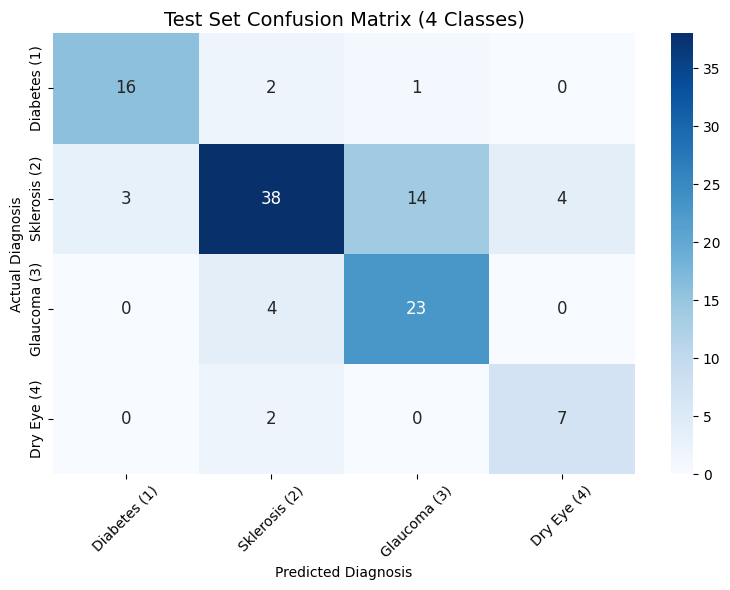

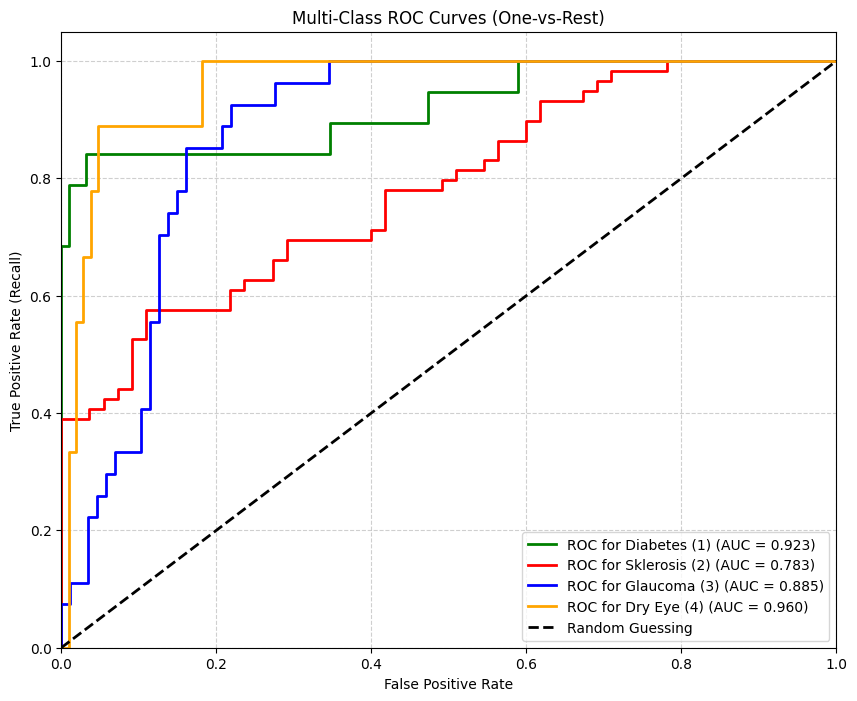

In [28]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

class_names = ['Diabetes (1)', 'Sklerosis (2)', 'Glaucoma (3)', 'Dry Eye (4)']
n_classes = len(class_names)

# ==========================================
# 1. RUN INFERENCE ON THE TEST SET
# ==========================================
model.eval()
all_predictions = []
all_true_labels = []
all_probabilities = []

with torch.no_grad():
    for images, features, labels in test_loader:
        images, features = images.to(device), features.to(device)
        
        # Get raw logits from the model
        outputs = model(images, features)
        
        # Convert logits to probabilities across the 5 classes using Softmax
        probs = torch.softmax(outputs, dim=1)
        
        # Get the predicted class by finding the index with the maximum probability
        _, preds = torch.max(probs, 1)
        
        # Store results
        all_probabilities.extend(probs.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)
all_probabilities = np.array(all_probabilities)


# ==========================================
# 2. CONFUSION MATRIX & CLASSIFICATION REPORT
# ==========================================
print("\n" + "="*60)
print("MULTI-CLASS CLASSIFICATION REPORT")
print("="*60)
print(classification_report(all_true_labels, all_predictions, target_names=class_names))

print("\n" + "="*60)
print("MULTI-CLASS CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(all_true_labels, all_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names,
            yticklabels=class_names,
            annot_kws={"size": 12})
plt.title('Test Set Confusion Matrix (4 Classes)', fontsize=14)
plt.ylabel('Actual Diagnosis')
plt.xlabel('Predicted Diagnosis')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ==========================================
# 3. MULTI-CLASS ROC CURVE (One-vs-Rest)
# ==========================================
# To plot ROC for multi-class, we must binarize the true labels
y_test_binarized = label_binarize(all_true_labels, classes=[0, 1, 2, 3])

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    # Calculate ROC for class 'i' vs the rest
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], all_probabilities[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = ['green', 'red', 'blue', 'orange', 'purple']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC for {class_names[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Multi-Class ROC Curves (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [37]:
torch.save(model.state_dict(), 'stage2_4class_disease_model.pth')

In [38]:
import joblib
joblib.dump(scaler, 'scaler_stage2.joblib')

['scaler_stage2.joblib']

In [36]:
dummy_img_stack = torch.randn(1, 2, 281, 281) 
dummy_feature_vector = torch.randn(1, 2) 

# 3. Use PyTorch's built-in "Tracer" to record the graph
# It runs the dummy data through the model and maps out every layer
traced_model = torch.jit.trace(model, (dummy_img_stack, dummy_feature_vector))

# 4. Save the mapped graph as a standard .pt file
traced_model.save("tear_model_graph.pt")